In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install --upgrade pip 

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install numpy 

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [17]:
from tensorflow.keras import layers, models

def create_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape,name='smoke_layer'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu',name='Yellow_Flame_Layer'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(128, (3, 3), activation='relu',name='Orange_Flame_Layer'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # Use 'softmax' for multiclass classification

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Adjust loss if multiclass
    return model
    model.add(layer.Fatten())
    model.add(layers.Dense(128,action='relu'))
    model.add(layers.Dense(10,action='softmax'))
    model.summary()


In [19]:
train_dir = 'dataset/train'
validation_dir = 'dataset/validation'

# Data Augmentation for training set
train_datagen = ImageDataGenerator(rescale=1./255, 
                                   rotation_range=40, 
                                   width_shift_range=0.2, 
                                   height_shift_range=0.2, 
                                   shear_range=0.2, 
                                   zoom_range=0.2, 
                                   horizontal_flip=True)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # Resize images as needed
    batch_size=32,
    class_mode='binary'  # Binary classification
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 105 images belonging to 2 classes.
Found 105 images belonging to 2 classes.


In [21]:
input_shape = (150, 150, 3)  # Image dimensions (height, width, channels)
model = create_cnn_model(input_shape)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=209,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

C:\Users\User1\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4521 - loss: 1.5021 - val_accuracy: 0.6146 - val_loss: 0.9941
Epoch 2/209
1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step - accuracy: 0.7812 - loss: 0.6142

C:\Users\User1\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 594ms/step - accuracy: 0.7812 - loss: 0.6142 - val_accuracy: 0.6771 - val_loss: 0.5936
Epoch 3/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3836 - loss: 0.7648 - val_accuracy: 0.4062 - val_loss: 0.6947
Epoch 4/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 580ms/step - accuracy: 0.3750 - loss: 0.6994 - val_accuracy: 0.7188 - val_loss: 0.6348
Epoch 5/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6986 - loss: 0.6325 - val_accuracy: 0.7292 - val_loss: 0.5537
Epoch 6/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.7188 - loss: 0.6511 - val_accuracy: 0.7292 - val_loss: 0.5644
Epoch 7/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.6979 - loss: 0.5734 - val_accuracy: 0.7708 - val_loss: 0.4948
Epoch 8/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step - accuracy: 0.8889 - loss: 0.4574 - val_accuracy: 0.7917 - val_loss: 0.4651
Epoch 9/209
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8082 - loss: 0.4944 - val_accuracy: 0.7396 - val_loss: 0.4753
Epoch 10

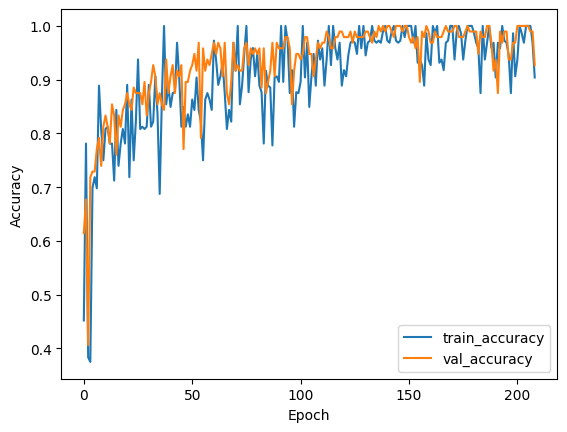

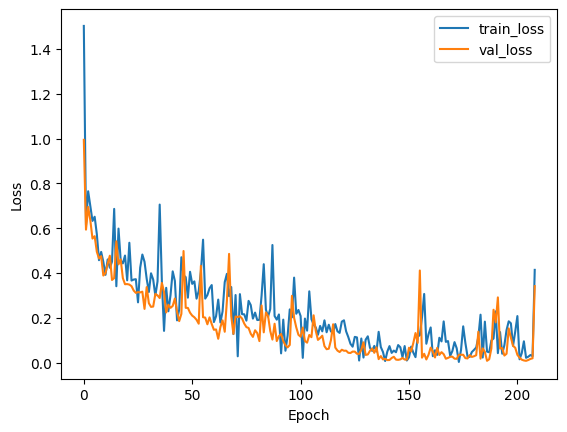

In [23]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Plotting training & validation loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [25]:
model.save('forest_fire_detection_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
[[99.750336]]
No Fire Detected


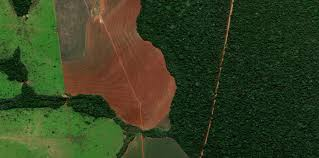

In [35]:
from tensorflow.keras.preprocessing import image
from IPython.display import Image, display
import numpy as np

image_path = r"C:\Users\User1\Downloads\forest16.jpg"
def predict_image(image_path, model):
    img = image.load_img(image_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize the image

    prediction = model.predict(img_array)
    print(prediction*100)
    if prediction < 0.5:
        print("Fire Detected")
    else:
        print("No Fire Detected")
predict_image(image_path, model)
display(Image(filename=image_path))